In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Student Test Score\train.csv")
print(data.shape)
data.head()

(630000, 13)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [4]:
def missing_values_table(df) :
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100*df.isnull().sum() / len(df)

    # Make a table with results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis = 1)

    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns ={0:'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,1]!=0].sort_values('% of Total Values', ascending = False).round(1)

    # Print some summary information
    print('Your selected dataframe has ' + str(df.shape[1]) + ' columns.\n'
          'There are ' + str(mis_val_table_ren_columns.shape[0]) + ' columns that have missing values !')

    # Return the dataframe with missing information
    return mis_val_table_ren_columns

missing_values_table(data)

Your selected dataframe has 13 columns.
There are 0 columns that have missing values !


,Missing Values,% of Total Values


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

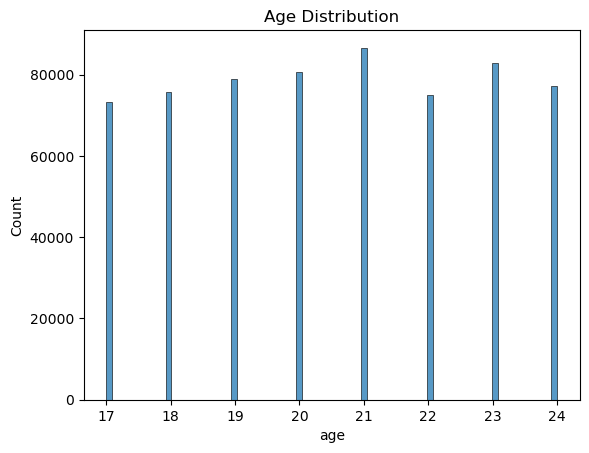

In [8]:
sns.histplot(data['age'])
plt.title('Age Distribution')
plt.show()

In [9]:
data['age'].describe()

count    630000.000000
mean         20.545821
std           2.260238
min          17.000000
25%          19.000000
50%          21.000000
75%          23.000000
max          24.000000
Name: age, dtype: float64

In [10]:
data['gender'].value_counts(normalize = True) *100

gender
other     33.507460
male      33.427460
female    33.065079
Name: proportion, dtype: float64

In [11]:
data['study_method'].value_counts(normalize = True) *100

study_method
coaching         20.904286
self-study       20.814444
mixed            19.537460
group study      19.525238
online videos    19.218571
Name: proportion, dtype: float64

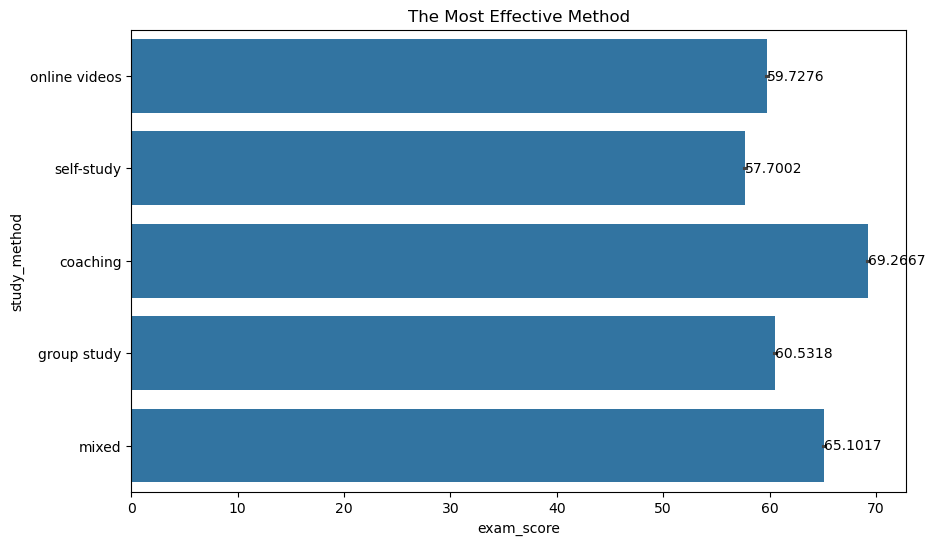

In [12]:
plt.figure(figsize = (10,6))
ax = sns.barplot(x = data['exam_score'], y = data['study_method'], legend = True )
ax.bar_label(ax.containers[0])
plt.title('The Most Effective Method')
plt.show()

In [13]:
data['exam_score'].describe()

count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64

In [14]:
data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


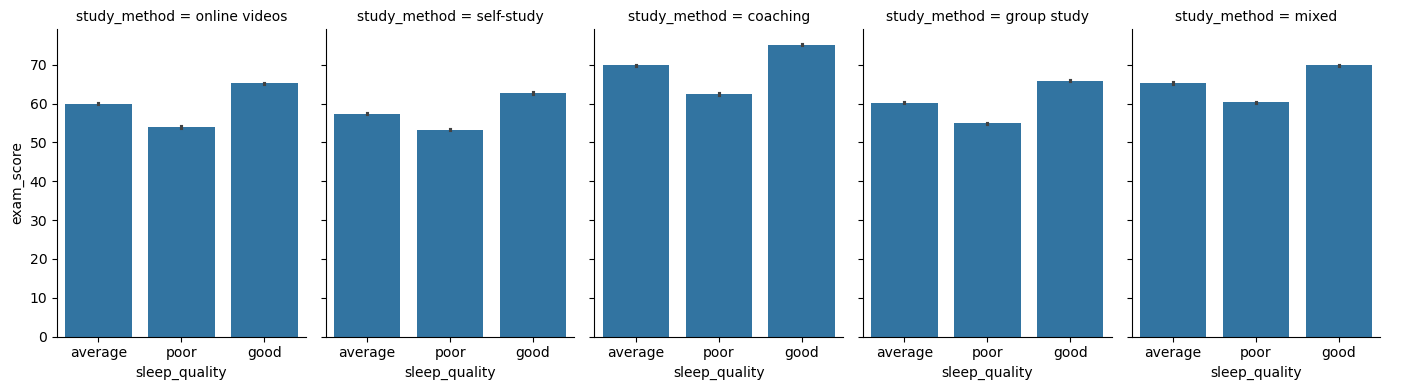

In [15]:
sns.catplot(
    data, kind = 'bar',
    x = 'sleep_quality', y = 'exam_score', col = 'study_method',
    height = 4, aspect = .7,
)

In [16]:
num_corr = data[['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']].corr()

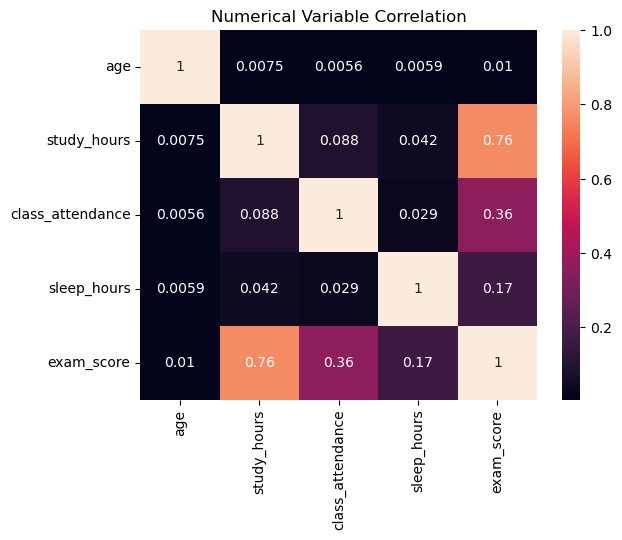

In [17]:
sns.heatmap(num_corr, annot = True)
plt.title('Numerical Variable Correlation')
plt.show()

In [18]:
data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [19]:
# Target and Features
train = data.copy()
y = train.exam_score
X = train.drop(columns = ['exam_score', 'id'])

In [20]:
y.head()

0     78.3
1     46.7
2     99.0
3     63.9
4    100.0
Name: exam_score, dtype: float64

In [21]:
X.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy


In [22]:
# The split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state = 0)

In [23]:
X_train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
628724,24,other,b.tech,0.77,89.5,yes,5.9,good,self-study,high,easy
388876,23,female,bba,2.31,49.3,yes,6.4,average,mixed,high,moderate
223800,23,female,b.com,0.11,61.2,yes,9.2,poor,mixed,high,easy
253003,19,other,b.com,7.71,79.0,yes,4.2,poor,mixed,high,hard
404249,21,female,b.com,6.64,44.4,yes,9.0,average,group study,low,hard


In [24]:
X_val.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
243132,18,other,diploma,3.23,82.6,no,8.3,poor,mixed,high,easy
258232,22,other,b.com,4.86,59.9,no,6.2,average,online videos,medium,moderate
395989,17,male,b.com,7.26,50.8,yes,9.3,poor,self-study,high,easy
376404,20,other,bba,7.91,83.8,yes,5.1,average,self-study,high,moderate
452357,18,male,b.com,1.24,88.6,yes,5.3,average,mixed,low,moderate


In [25]:
y_train.head()

628724    39.6
388876    57.2
223800    41.3
253003    88.3
404249    61.7
Name: exam_score, dtype: float64

In [26]:
y_val.head()

243132     57.5
258232     69.2
395989     79.9
376404    100.0
452357     46.5
Name: exam_score, dtype: float64

In [27]:
def df_mapping(df) :
    df['internet_access'] = df['internet_access'].map({'yes' : 1, 'no' : 0})
    df['sleep_quality'] = df['sleep_quality'].map({'good' : 2, 'average' : 1, 'poor' : 0})
    df['facility_rating'] = df['facility_rating'].map({'high' : 2, 'medium' : 1, 'low' : 0})
    df['exam_difficulty'] = df['exam_difficulty'].map({'hard' : 2, 'moderate' : 1, 'easy' : 0})
    return df.head()

In [28]:
df_mapping(X_train)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
628724,24,other,b.tech,0.77,89.5,1,5.9,2,self-study,2,0
388876,23,female,bba,2.31,49.3,1,6.4,1,mixed,2,1
223800,23,female,b.com,0.11,61.2,1,9.2,0,mixed,2,0
253003,19,other,b.com,7.71,79.0,1,4.2,0,mixed,2,2
404249,21,female,b.com,6.64,44.4,1,9.0,1,group study,0,2


In [29]:
df_mapping(X_val)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
243132,18,other,diploma,3.23,82.6,0,8.3,0,mixed,2,0
258232,22,other,b.com,4.86,59.9,0,6.2,1,online videos,1,1
395989,17,male,b.com,7.26,50.8,1,9.3,0,self-study,2,0
376404,20,other,bba,7.91,83.8,1,5.1,1,self-study,2,1
452357,18,male,b.com,1.24,88.6,1,5.3,1,mixed,0,1


In [30]:
# Categorical and numerical variables
num_cols = [cname for cname in X_train.columns if X_train[cname].dtypes in ['float64', 'int64']]
cat_cols = [cname for cname in X_train.columns if X_train[cname].dtypes == 'object']

In [31]:
X_train[num_cols].head()

,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty
628724,24,0.77,89.5,1,5.9,2,2,0
388876,23,2.31,49.3,1,6.4,1,2,1
223800,23,0.11,61.2,1,9.2,0,2,0
253003,19,7.71,79.0,1,4.2,0,2,2
404249,21,6.64,44.4,1,9.0,1,0,2


In [32]:
X_train[cat_cols].head()

,gender,course,study_method
628724,other,b.tech,self-study
388876,female,bba,mixed
223800,female,b.com,mixed
253003,other,b.com,mixed
404249,female,b.com,group study


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [34]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cat_cols)
    ], remainder = 'passthrough'
)

In [35]:
from xgboost import XGBRegressor

In [61]:
my_model = XGBRegressor(
    n_estimators = 600,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    eval_metric = 'rmse'
)
pipeline = Pipeline([('prep', preprocessor), ('model', my_model)])

from sklearn.metrics import root_mean_squared_error
pipeline.fit(X_train, y_train)
val_preds = pipeline.predict(X_val)
print(f'RMSE : {root_mean_squared_error(y_val, val_preds)}')

RMSE : 8.763786079995695


In [44]:
test = pd.read_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Student Test Score\test.csv")
test.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [46]:
test_id = test.id
X_test = test.drop(columns = 'id')

In [47]:
df_mapping(X_test)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,24,other,ba,6.85,65.2,1,5.2,0,group study,2,0
1,18,male,diploma,6.61,45.0,0,9.3,0,coaching,0,0
2,24,female,b.tech,6.60,98.5,1,6.2,2,group study,1,1
3,24,male,diploma,3.03,66.3,1,5.7,1,mixed,1,1
4,20,female,b.tech,2.03,42.4,1,9.2,1,coaching,0,1


In [48]:
final = pipeline.predict(X_test)

In [49]:
final

array([70.103546, 69.80061 , 88.20208 , ..., 91.114426, 54.378906,
       67.19403 ], dtype=float32)

In [50]:
submission = pd.DataFrame({'id' : test_id, 'exam_score' : final})

In [52]:
submission.to_csv(r'S:\Project Portfolio\Tutorials\Kaggle Competition\Student Test Score\submission.csv', index = False)